Daniel Badaire, Manuel Griseri, Clément Chivet

# Trading haute fréquence optimal avec ordres à cours limité et au marché


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from time import time as _clock
from matplotlib.colors import ListedColormap, BoundaryNorm

# Graine aléatoire pour la reproductibilité
np.random.seed(42)

# Configuration matplotlib
plt.rcParams.update({
    'figure.dpi': 100,
    'savefig.dpi': 150,
    'font.size': 10,
    'figure.figsize': (9, 6),
})

## 1. Paramètres calibrés sur les données de marché

In [ ]:
# Matrice de transition ρ_ij pour le spread (Tableau 1)
# Lignes / colonnes : spread = i*δ pour i = 1, ..., 6 (δ = 0.005)
rho_paper = np.array([
    [0.000, 0.410, 0.220, 0.160, 0.142, 0.065],
    [0.201, 0.000, 0.435, 0.192, 0.103, 0.067],
    [0.113, 0.221, 0.000, 0.4582, 0.147, 0.059],
    [0.070, 0.085, 0.275, 0.000,  0.465, 0.102],
    [0.068, 0.049, 0.073, 0.363,  0.000, 0.446],
    [0.077, 0.057, 0.059, 0.112,  0.692, 0.000],
])
# Renormalisation des lignes (elles doivent sommer à 1)
rho_paper = rho_paper / rho_paper.sum(axis=1, keepdims=True)

# Intensité de l'horloge tick-time λ(t) (Tableau 2)
clock_hours  = np.array([10.5, 11.5, 12.5, 13.5, 14.5, 15.5, 16.5])  # heures
clock_lambda = np.array([1.654, 0.799, 0.516, 0.377, 0.632, 1.305, 2.113])

# Intensités d'exécution λ^a_i(q), λ^b_i(q) (Tableau 3)
# Lignes : spread = i*δ pour i=1..6
# Colonnes : Ba, Ba-, Bb, Bb+
lambda_exec_paper = np.array([
    [0.0539, 0.1485, 0.0718, 0.1763],
    [0.0465, 0.0979, 0.0520, 0.1144],
    [0.0401, 0.0846, 0.0419, 0.0915],
    [0.0360, 0.0856, 0.0409, 0.0896],
    [0.0435, 0.1009, 0.0452, 0.0930],
    [0.0554, 0.1202, 0.0614, 0.1255],
])

# Version symétrisée (utilisée dans la section 4 pour le backtest)
# Colonnes : [best (Bb ou Ba), improved (Bb+ ou Ba-)]
lambda_sym = np.column_stack([
    (lambda_exec_paper[:, 0] + lambda_exec_paper[:, 2]) / 2,  # best
    (lambda_exec_paper[:, 1] + lambda_exec_paper[:, 3]) / 2,  # improved
])

# Paramètres de marché (Tableau 4a)
delta      = 0.005    # Taille du tick
rho_rebate = 0.0008   # Rabais par action (pour ordres limit exécutés)
eps_fee    = 0.0012   # Frais par action (pour ordres market)
eps_0      = 1e-6     # Frais fixes par transaction
lambda_const = 1.0    # Intensité horloge tick constante (backtest) en s^-1

# Paramètres d'optimisation (Tableau 4b)
gamma_default = 5.0   # Pénalisation d'inventaire (Tableau 4b)
l_bar         = 100   # Volume maximum des ordres limit
e_bar         = 100   # Volume maximum des ordres market

# Échelle de normalisation de l'inventaire pour la pénalité g(y) = (y/Y_SCALE)^2
Y_SCALE = 1000.0

# Paramètres de discrétisation (Tableau 4c)
T_horizon   = 300.0   # Horizon en secondes
y_min       = -1000
y_max       = 1000
# NB : le papier indique n=100. Cependant, le schéma Euler explicite utilisé
# ici pour résoudre le système d'IDEs nécessite un pas de temps suffisamment
# petit pour assurer la stabilité numérique : la condition est
#     dt * (λ_clock + max λ^b + max λ^a) ≤ 1
# Avec λ_clock ≈ 1, λ ≈ 0.2, on doit avoir dt ≤ ~0.8 s, soit n_t ≥ 400.
# On utilise donc n_t=600 (dt=0.5s) qui garantit la stabilité.
n_t         = 600     # Nombre de pas de temps
m_spreads   = 6       # Nombre de valeurs de spread

# Paramètres de backtest (Tableau 4d)
# Note : le papier utilise N_MC=10^5.
N_MC    = 10_000      # Nombre de trajectoires Monte Carlo
dt_sim  = 0.3         # Pas de temps Euler
l_0     = 100         # Quantité B/A pour stratégies benchmark
x_0_init = 0.0
y_0_init = 0
p_0_init = 45.0
# Volatilité (modèle Bachelier pour le prix mid, martingale).
# Ce paramètre n'est pas explicité dans le papier : on le fixe ici pour que
# la σ(X_T) de la stratégie constante corresponde approximativement au
# papier (~51 euros). σ_P ~0.005 €/√s correspond à ~27% de volatilité annualisée.
sigma_P = 0.005

# Grilles numériques
dy          = 5                             # pas de la grille d'inventaire
Y_grid      = np.arange(y_min, y_max + dy, dy)
N_y         = len(Y_grid)
L_grid      = np.arange(0, l_bar + 1, dy)   # tailles d'ordres limit
N_l         = len(L_grid)
E_grid      = np.arange(-e_bar, e_bar + 1, dy)  # tailles d'ordres market
N_e         = len(E_grid)
spreads     = np.arange(1, m_spreads + 1) * delta   # valeurs du spread en euros

print("Paramètres chargés.")
print(f"  Grille y : {N_y} points, pas dy={dy}")
print(f"  Grille l : {N_l} points")
print(f"  Grille e : {N_e} points")
print(f"  Temps    : n_t={n_t}, dt={T_horizon/n_t}s")

Paramètres chargés.
  Grille y : 401 points, pas dy=5
  Grille l : 21 points
  Grille e : 41 points
  Temps    : n_t=600, dt=0.5s


In [ ]:
# Tableau 1 : matrice de transition
print("\n" + "=" * 70)
print("TABLEAU 1 : Matrice de transition du spread (SOGN.PA, 18/04/2011)")
print("=" * 70)
df_rho = pd.DataFrame(
    rho_paper,
    index=[f"{s:.3f}" for s in spreads],
    columns=[f"{s:.3f}" for s in spreads],
)
df_rho.index.name = "spread"
print(df_rho.round(3).to_string())


TABLEAU 1 : Matrice de transition du spread (SOGN.PA, 18/04/2011)
        0.005  0.010  0.015  0.020  0.025  0.030
spread                                          
0.005   0.000  0.411  0.221  0.160  0.142  0.065
0.010   0.201  0.000  0.436  0.192  0.103  0.067
0.015   0.113  0.221  0.000  0.459  0.147  0.059
0.020   0.070  0.085  0.276  0.000  0.466  0.102
0.025   0.068  0.049  0.073  0.363  0.000  0.446
0.030   0.077  0.057  0.059  0.112  0.694  0.000


In [ ]:
# Tableau 2 : intensité horloge tick-time
print("\n" + "=" * 70)
print("TABLEAU 2 : Intensité horloge tick-time (s^-1)")
print("=" * 70)
df_lambda_t = pd.DataFrame({
    "Heure":     [f"{int(h):02d}:30" for h in clock_hours],
    "λ(t)":      clock_lambda,
})
print(df_lambda_t.to_string(index=False))


TABLEAU 2 : Intensité horloge tick-time (s^-1)
Heure  λ(t)
10:30 1.654
11:30 0.799
12:30 0.516
13:30 0.377
14:30 0.632
15:30 1.305
16:30 2.113


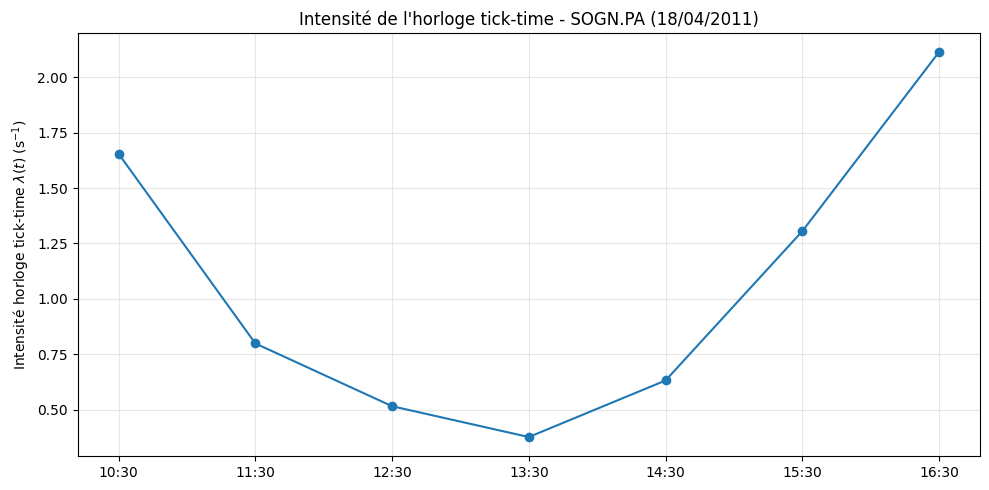

In [ ]:
# Figure 1 : intensité horloge tick-time
fig1, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(clock_hours, clock_lambda, marker='o', linestyle='-', color='C0')
ax1.set_xticks(clock_hours)
ax1.set_xticklabels([f"{int(h):02d}:30" for h in clock_hours])
ax1.set_ylabel(r"Intensité horloge tick-time $\lambda(t)$ (s$^{-1}$)")
ax1.set_title("Intensité de l'horloge tick-time - SOGN.PA (18/04/2011)")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figure1_clock_intensity.png", bbox_inches='tight')
plt.show()

In [ ]:
# Tableau 3 : intensités d'exécution
print("\n" + "=" * 70)
print("TABLEAU 3 : Intensités d'exécution (s^-1)")
print("=" * 70)
df_exec = pd.DataFrame(
    lambda_exec_paper,
    index=[f"{s:.3f}" for s in spreads],
    columns=["Ba", "Ba-", "Bb", "Bb+"],
)
df_exec.index.name = "spread"
print(df_exec.round(4).to_string())


TABLEAU 3 : Intensités d'exécution (s^-1)
            Ba     Ba-      Bb     Bb+
spread                                
0.005   0.0539  0.1485  0.0718  0.1763
0.010   0.0465  0.0979  0.0520  0.1144
0.015   0.0401  0.0846  0.0419  0.0915
0.020   0.0360  0.0856  0.0409  0.0896
0.025   0.0435  0.1009  0.0452  0.0930
0.030   0.0554  0.1202  0.0614  0.1255


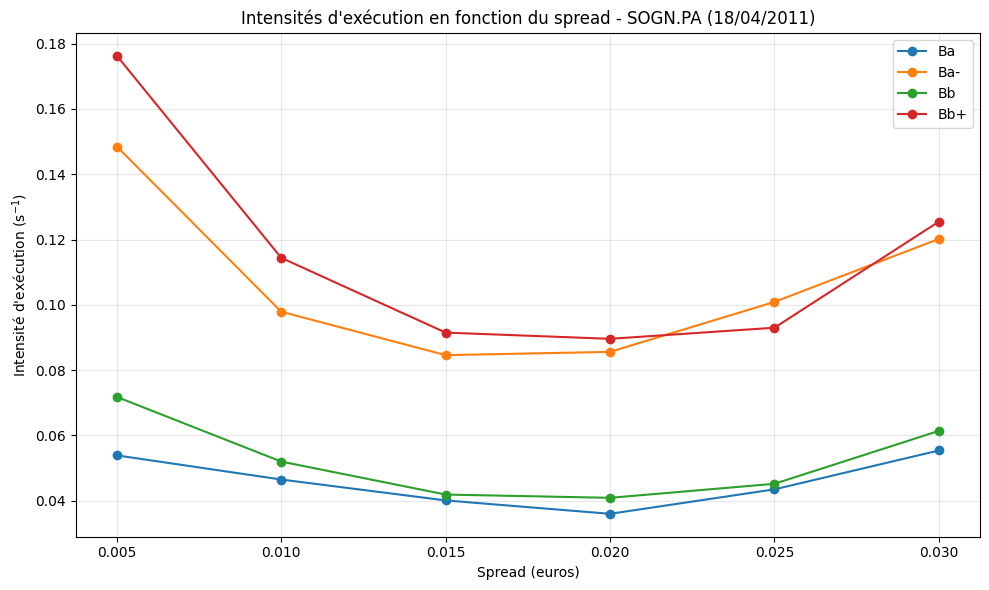

In [ ]:
# Figure 2 : intensités d'exécution en fonction du spread
fig2, ax2 = plt.subplots(figsize=(10, 6))
for col_idx, col_name in enumerate(["Ba", "Ba-", "Bb", "Bb+"]):
    ax2.plot(spreads, lambda_exec_paper[:, col_idx],
             marker='o', label=col_name)
ax2.set_xlabel("Spread (euros)")
ax2.set_ylabel(r"Intensité d'exécution (s$^{-1}$)")
ax2.set_title("Intensités d'exécution en fonction du spread - SOGN.PA (18/04/2011)")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figure2_execution_intensities.png", bbox_inches='tight')
plt.show()

## 2. Estimation des paramètres par simulation

In [ ]:
def simulate_spread_path(T_sec, rho_mat, lam_fn, s_init=3, rng=None):
    """
    Simule une trajectoire du spread selon le modèle :
    - Sauts selon un processus de Poisson d'intensité λ(t)
    - Transitions selon la matrice ρ
    Retourne : temps de saut et valeurs du spread (en indices 1..m).
    """
    if rng is None:
        rng = np.random.default_rng()
    m = rho_mat.shape[0]
    # Thinning avec une borne supérieure pour λ(t)
    lam_max = 3.0
    t = 0.0
    s = s_init
    jump_times = [0.0]
    spread_vals = [s]
    while t < T_sec:
        dt_c = rng.exponential(1.0 / lam_max)
        t_c = t + dt_c
        if t_c >= T_sec:
            break
        if rng.uniform() < lam_fn(t_c) / lam_max:
            t = t_c
            s_new = rng.choice(m, p=rho_mat[s - 1]) + 1
            if s_new != s:
                jump_times.append(t)
                spread_vals.append(s_new)
                s = s_new
        else:
            t = t_c
    return np.array(jump_times), np.array(spread_vals)

def estimate_transition_matrix(S_hat, m):
    """
    Estimateur empirique de la matrice de transition (éq. 2.6 du papier).
    S_hat : séquence d'états du spread en temps tick (indices 1..m).
    """
    rho_hat = np.zeros((m, m))
    cnt = np.zeros((m, m))
    for n in range(len(S_hat) - 1):
        cnt[S_hat[n] - 1, S_hat[n + 1] - 1] += 1
    for i in range(m):
        tot = cnt[i].sum()
        if tot > 0:
            rho_hat[i] = cnt[i] / tot
    return rho_hat

def estimate_clock_intensity(jump_times, time_bins):
    """
    Estimateur de l'intensité horloge tick-time (éq. 2.7 du papier).
    Intensité supposée constante par morceaux sur les intervalles [tk, tk+1].
    """
    out = np.zeros(len(time_bins) - 1)
    for k in range(len(time_bins) - 1):
        cnt = np.sum((jump_times > time_bins[k]) & (jump_times <= time_bins[k + 1]))
        out[k] = cnt / (time_bins[k + 1] - time_bins[k])
    return out

def lambda_from_table(t):
    """Retourne λ(t) par interpolation linéaire du tableau 2 (pour la simulation)."""
    return np.interp(t / 3600.0, clock_hours, clock_lambda)

In [ ]:
# Simulation d'une journée de trading (7 heures)
print("\n" + "=" * 70)
print("DÉMONSTRATION DES PROCÉDURES D'ESTIMATION (sur données simulées)")
print("=" * 70)
t_start_est = _clock()
T_sec_day = 7 * 3600  # 9:30 -> 16:30
rng_est = np.random.default_rng(123)
# Fonction λ(t) en seconde (décalée pour commencer à t=0 à 9:30)
def lam_fn_day(t_sec):
    h = 9.5 + t_sec / 3600.0
    return np.interp(h, clock_hours, clock_lambda)

jt, sv = simulate_spread_path(T_sec_day, rho_paper, lam_fn_day, s_init=3, rng=rng_est)

# Estimation de la matrice de transition
rho_hat = estimate_transition_matrix(sv, m_spreads)
print("\nMatrice de transition estimée (sur données simulées):")
print(pd.DataFrame(rho_hat, index=[f"{s:.3f}" for s in spreads],
                   columns=[f"{s:.3f}" for s in spreads]).round(3).to_string())

# Estimation de l'intensité horloge
time_bins_sec = np.array([0, 1, 2, 3, 4, 5, 6, 7]) * 3600
lam_hat = estimate_clock_intensity(jt, time_bins_sec)
print("\nIntensité horloge estimée (sur données simulées):")
for h, l in zip(clock_hours, lam_hat):
    print(f"  {int(h):02d}:30 -> {l:.3f} s^-1")

print(f"\n(Temps de simulation+estimation : {_clock()-t_start_est:.1f}s)")
print("NB : les intensités d'exécution λ^a_i, λ^b_i requièrent des données de "
      "carnet d'ordres (Level 2) ; on utilise directement les valeurs du Tableau 3.")


DÉMONSTRATION DES PROCÉDURES D'ESTIMATION (sur données simulées)

Matrice de transition estimée (sur données simulées):
       0.005  0.010  0.015  0.020  0.025  0.030
0.005  0.000  0.410  0.223  0.164  0.141  0.062
0.010  0.213  0.000  0.432  0.184  0.104  0.068
0.015  0.116  0.229  0.000  0.455  0.146  0.053
0.020  0.068  0.088  0.275  0.000  0.458  0.110
0.025  0.067  0.048  0.078  0.360  0.000  0.447
0.030  0.067  0.055  0.068  0.116  0.694  0.000

Intensité horloge estimée (sur données simulées):
  10:30 -> 1.672 s^-1
  11:30 -> 1.190 s^-1
  12:30 -> 0.630 s^-1
  13:30 -> 0.438 s^-1
  14:30 -> 0.517 s^-1
  15:30 -> 0.937 s^-1
  16:30 -> 1.666 s^-1

(Temps de simulation+estimation : 1.0s)
NB : les intensités d'exécution λ^a_i, λ^b_i requièrent des données de carnet d'ordres (Level 2) ; on utilise directement les valeurs du Tableau 3.


## 3. Résolution du système HJB-QVI

In [ ]:
def solve_hjb_qvi(gamma,
                  enable_market=True,
                  lambda_clock_val=lambda_const,
                  rho_mat=rho_paper,
                  lambda_exec_mat=lambda_sym,
                  verbose=True):
    """
    Résout le système d'IDEs pour φ_i(t, y) dans le cas moyenne-variance
    (U(x) = x, g(y) = y^2) par différences finies explicites.

    L'ansatz v_i(t, x, y, p) = x + y*p + φ_i(t, y) réduit le problème à un
    système en (t, y, i). On résout :
        - ∂φ_i/∂t - Σ_j r_ij[φ_j - φ_i]
        - sup_{q_b, l_b} λ^b_i(q_b)[φ_i(t,y+l_b) - φ_i(t,y) + l_b*coef_b]
        - sup_{q_a, l_a} λ^a_i(q_a)[φ_i(t,y-l_a) - φ_i(t,y) + l_a*coef_a]
        + γ*y^2  = 0
    avec la contrainte d'obstacle pour les ordres market.

    Retourne :
        phi        : (n_t+1, m, N_y)
        pol_take   : (n_t+1, m, N_y) booléen, True si trade au marché
        pol_e      : idem, taille e* optimale
        pol_qb     : idem, 0=Bb, 1=Bb+
        pol_lb     : idem, l_b* optimal
        pol_qa     : idem, 0=Ba, 1=Ba-
        pol_la     : idem, l_a* optimal
    """
    dt = T_horizon / n_t

    # Matrice d'intensité R : r_ij = λ * ρ_ij (i≠j), r_ii = -λ (car ρ_ii = 0, Σρ = 1)
    R = lambda_clock_val * (rho_mat - np.eye(m_spreads))

    # Initialisation
    phi = np.zeros((n_t + 1, m_spreads, N_y))
    # Condition terminale : φ_i(T, y) = -|y|*(iδ/2 + ε_fee) - ε_0
    for i in range(m_spreads):
        phi[n_t, i, :] = -np.abs(Y_grid) * (spreads[i] / 2 + eps_fee) - eps_0

    # Politiques optimales
    pol_take = np.zeros((n_t + 1, m_spreads, N_y), dtype=bool)
    pol_e    = np.zeros((n_t + 1, m_spreads, N_y))
    pol_qb   = np.zeros((n_t + 1, m_spreads, N_y), dtype=int)
    pol_lb   = np.zeros((n_t + 1, m_spreads, N_y))
    pol_qa   = np.zeros((n_t + 1, m_spreads, N_y), dtype=int)
    pol_la   = np.zeros((n_t + 1, m_spreads, N_y))

    # Pré-calcul des décalages pour chaque l ∈ L_grid
    # shift_bid[k, y] = φ(y + L_grid[k]) ; out-of-bounds = -inf
    # shift_ask[k, y] = φ(y - L_grid[k])
    # On reconstruit à chaque pas de temps.

    # Indices pour décaler (en nombre de cellules de la grille)
    l_shifts = (L_grid // dy).astype(int)
    e_shifts = (E_grid // dy).astype(int)

    t_start = _clock()
    for n in range(n_t - 1, -1, -1):
        phi_next = phi[n + 1]  # (m, N_y)

        for i in range(m_spreads):
            phi_i = phi_next[i]
            s_i = spreads[i]

            # Terme de régime switching
            regime = np.zeros(N_y)
            for j in range(m_spreads):
                if j != i:
                    regime += R[i, j] * (phi_next[j] - phi_i)

            # Côté bid : max sur (q_b ∈ {Bb, Bb+}, l_b)
            # Construction des décalages φ_i(y + l)
            shifts_bid = np.full((N_l, N_y), -np.inf)
            for k, sh in enumerate(l_shifts):
                if sh == 0:
                    shifts_bid[k] = phi_i
                elif sh < N_y:
                    shifts_bid[k, :N_y - sh] = phi_i[sh:]

            # qb_idx = 0 : Bb  ;  qb_idx = 1 : Bb+
            # coef_b = s_i/2 - δ*qb_idx + ρ_rebate
            # Ordre Bb+ interdit si spread = δ (i=0)
            lam_bid = np.array([lambda_exec_mat[i, 0], lambda_exec_mat[i, 1]])
            coef_bid = np.array([s_i / 2 + rho_rebate,
                                 s_i / 2 - delta + rho_rebate])
            # val[qb, k, y] = λ(qb) * (shifts_bid[k, y] - phi_i[y] + L[k]*coef[qb])
            # shape (2, N_l, N_y)
            val_bid = (lam_bid[:, None, None]
                       * (shifts_bid[None, :, :] - phi_i[None, None, :]
                          + L_grid[None, :, None] * coef_bid[:, None, None]))
            if i == 0:
                val_bid[1] = -np.inf  # Bb+ interdit au spread = δ

            # Meilleur choix + argmax
            val_bid_flat = val_bid.reshape(-1, N_y)  # (2*N_l, N_y)
            idx_bid = np.argmax(val_bid_flat, axis=0)
            bid_best = val_bid_flat[idx_bid, np.arange(N_y)]
            # Décodage des indices
            best_qb_idx = idx_bid // N_l
            best_lb_idx = idx_bid % N_l

            # Côté ask : max sur (q_a ∈ {Ba, Ba-}, l_a)
            shifts_ask = np.full((N_l, N_y), -np.inf)
            for k, sh in enumerate(l_shifts):
                if sh == 0:
                    shifts_ask[k] = phi_i
                elif sh < N_y:
                    shifts_ask[k, sh:] = phi_i[:N_y - sh]

            lam_ask = np.array([lambda_exec_mat[i, 0], lambda_exec_mat[i, 1]])
            coef_ask = np.array([s_i / 2 + rho_rebate,
                                 s_i / 2 - delta + rho_rebate])
            val_ask = (lam_ask[:, None, None]
                       * (shifts_ask[None, :, :] - phi_i[None, None, :]
                          + L_grid[None, :, None] * coef_ask[:, None, None]))
            if i == 0:
                val_ask[1] = -np.inf

            val_ask_flat = val_ask.reshape(-1, N_y)
            idx_ask = np.argmax(val_ask_flat, axis=0)
            ask_best = val_ask_flat[idx_ask, np.arange(N_y)]
            best_qa_idx = idx_ask // N_l
            best_la_idx = idx_ask % N_l

            # Valeur "make" (Euler explicite)
            # Pénalité d'inventaire : g(y) = (y/Y_SCALE)^2
            penalty = gamma * (Y_grid.astype(float) / Y_SCALE) ** 2
            phi_make = phi_i + dt * (regime + bid_best + ask_best - penalty)

            # Valeur "take" (obstacle impulse)
            # On itère M sur phi jusqu'à stabilité.
            # M phi(y) = sup_{e != 0} [phi(y+e) - |e|*(s_i/2 + eps_fee) - eps_0]
            # Exclut explicitement e=0 (pas de "trade nul")
            if enable_market:
                # Coûts par action (excluant e=0)
                mask_nonzero = E_grid != 0
                costs = np.abs(E_grid) * (s_i / 2 + eps_fee) + eps_0
                costs_arr = np.where(mask_nonzero, costs, np.inf)  # Bloque e=0

                phi_curr = phi_make.copy()
                for _iter in range(5):  # Itérations pour convergence
                    shifts_e = np.full((N_e, N_y), -np.inf)
                    for k, sh in enumerate(e_shifts):
                        if sh == 0:
                            shifts_e[k] = phi_curr
                        elif sh > 0 and sh < N_y:
                            shifts_e[k, :N_y - sh] = phi_curr[sh:]
                        elif sh < 0 and -sh < N_y:
                            shifts_e[k, -sh:] = phi_curr[:N_y + sh]

                    val_take = shifts_e - costs_arr[:, None]
                    idx_take = np.argmax(val_take, axis=0)
                    take_best = val_take[idx_take, np.arange(N_y)]
                    phi_new = np.maximum(phi_make, take_best)
                    if np.allclose(phi_new, phi_curr, atol=1e-10):
                        break
                    phi_curr = phi_new

                phi[n, i, :] = phi_curr
                use_market = take_best > phi_make + 1e-9  # seuil de tolérance
                pol_take[n, i, :] = use_market
                # e* optimal pour les points où on trade
                pol_e[n, i, :] = np.where(use_market, E_grid[idx_take], 0)
            else:
                phi[n, i, :] = phi_make

            pol_qb[n, i, :] = best_qb_idx
            pol_lb[n, i, :] = L_grid[best_lb_idx]
            pol_qa[n, i, :] = best_qa_idx
            pol_la[n, i, :] = L_grid[best_la_idx]

        if verbose and n % 20 == 0:
            print(f"  HJB backward step n={n} ({(n_t-n)/n_t*100:.0f}% terminé)")

    if verbose:
        print(f"  HJB QVI résolu en {_clock()-t_start:.1f}s")

    return phi, pol_take, pol_e, pol_qb, pol_lb, pol_qa, pol_la

In [ ]:
print("\n" + "=" * 70)
print("RÉSOLUTION DU SYSTÈME HJB-QVI (stratégie optimale α*)")
print("=" * 70)
phi_opt, pt_opt, pe_opt, pqb_opt, plb_opt, pqa_opt, pla_opt = solve_hjb_qvi(
    gamma=gamma_default, enable_market=True)


RÉSOLUTION DU SYSTÈME HJB-QVI (stratégie optimale α*)
  HJB backward step n=580 (3% terminé)
  HJB backward step n=560 (7% terminé)
  HJB backward step n=540 (10% terminé)
  HJB backward step n=520 (13% terminé)
  HJB backward step n=500 (17% terminé)
  HJB backward step n=480 (20% terminé)
  HJB backward step n=460 (23% terminé)
  HJB backward step n=440 (27% terminé)
  HJB backward step n=420 (30% terminé)
  HJB backward step n=400 (33% terminé)
  HJB backward step n=380 (37% terminé)
  HJB backward step n=360 (40% terminé)
  HJB backward step n=340 (43% terminé)
  HJB backward step n=320 (47% terminé)
  HJB backward step n=300 (50% terminé)
  HJB backward step n=280 (53% terminé)
  HJB backward step n=260 (57% terminé)
  HJB backward step n=240 (60% terminé)
  HJB backward step n=220 (63% terminé)
  HJB backward step n=200 (67% terminé)
  HJB backward step n=180 (70% terminé)
  HJB backward step n=160 (73% terminé)
  HJB backward step n=140 (77% terminé)
  HJB backward step n=120 (

In [ ]:
print("\nRÉSOLUTION DU SYSTÈME HJB-QVI (stratégie WoMO α^w)")
phi_wmo, pt_wmo, pe_wmo, pqb_wmo, plb_wmo, pqa_wmo, pla_wmo = solve_hjb_qvi(
    gamma=gamma_default, enable_market=False)


RÉSOLUTION DU SYSTÈME HJB-QVI (stratégie WoMO α^w)
  HJB backward step n=580 (3% terminé)
  HJB backward step n=560 (7% terminé)
  HJB backward step n=540 (10% terminé)
  HJB backward step n=520 (13% terminé)
  HJB backward step n=500 (17% terminé)
  HJB backward step n=480 (20% terminé)
  HJB backward step n=460 (23% terminé)
  HJB backward step n=440 (27% terminé)
  HJB backward step n=420 (30% terminé)
  HJB backward step n=400 (33% terminé)
  HJB backward step n=380 (37% terminé)
  HJB backward step n=360 (40% terminé)
  HJB backward step n=340 (43% terminé)
  HJB backward step n=320 (47% terminé)
  HJB backward step n=300 (50% terminé)
  HJB backward step n=280 (53% terminé)
  HJB backward step n=260 (57% terminé)
  HJB backward step n=240 (60% terminé)
  HJB backward step n=220 (63% terminé)
  HJB backward step n=200 (67% terminé)
  HJB backward step n=180 (70% terminé)
  HJB backward step n=160 (73% terminé)
  HJB backward step n=140 (77% terminé)
  HJB backward step n=120 (80%

## 4. Zones de la politique optimale

In [ ]:
def plot_policy_slice(pol_take_arr, pol_qb_arr, pol_qa_arr, n_idx, title, fname):
    """
    Trace la 'forme stylisée' de la politique optimale dans le plan (y, s).
    Zones : BUY AT MARKET (vert clair), SELL AT MARKET (rouge clair),
    et zones make subdivisées selon (q_b, q_a).
    """
    # Construction d'une matrice de zones (spread × y)
    # Code : 0=Bb,Ba  1=Bb+,Ba  2=Bb,Ba-  3=Bb+,Ba-  4=BUY market  5=SELL market
    zone = np.zeros((m_spreads, N_y))
    for i in range(m_spreads):
        for j in range(N_y):
            if pol_take_arr[n_idx, i, j]:
                # Trade au marché : vérifier le signe de e*
                # On utilise y pour déterminer BUY ou SELL par héritage
                # Mais plus propre : on regarde directement pol_e
                # Ici simplification : y > 0 -> vend, y < 0 -> achète
                if Y_grid[j] >= 0:
                    zone[i, j] = 5  # SELL
                else:
                    zone[i, j] = 4  # BUY
            else:
                qb = pol_qb_arr[n_idx, i, j]
                qa = pol_qa_arr[n_idx, i, j]
                zone[i, j] = 2 * qa + qb  # 0..3

    fig, ax = plt.subplots(figsize=(11, 6))
    colors = ['#d4e6f1', '#a9dfbf', '#f9e79f', '#f5b7b1',
              '#2ecc71', '#e74c3c']
    labels = ['Ba, Bb', 'Ba, Bb+', 'Ba-, Bb', 'Ba-, Bb+',
              'BUY AT MARKET', 'SELL AT MARKET']
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(np.arange(-0.5, 6.5, 1), cmap.N)
    im = ax.imshow(zone, aspect='auto', origin='lower', cmap=cmap, norm=norm,
                   extent=[Y_grid[0], Y_grid[-1], spreads[0], spreads[-1]],
                   interpolation='nearest')
    cbar = fig.colorbar(im, ax=ax, ticks=range(6))
    cbar.ax.set_yticklabels(labels)
    ax.axvline(0, color='k', linestyle='--', alpha=0.5, label='Y=0')
    ax.set_xlabel("Y (nombre d'actions)")
    ax.set_ylabel("S (Spread)")
    ax.set_title(title)
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig(fname, bbox_inches='tight')
    plt.show()

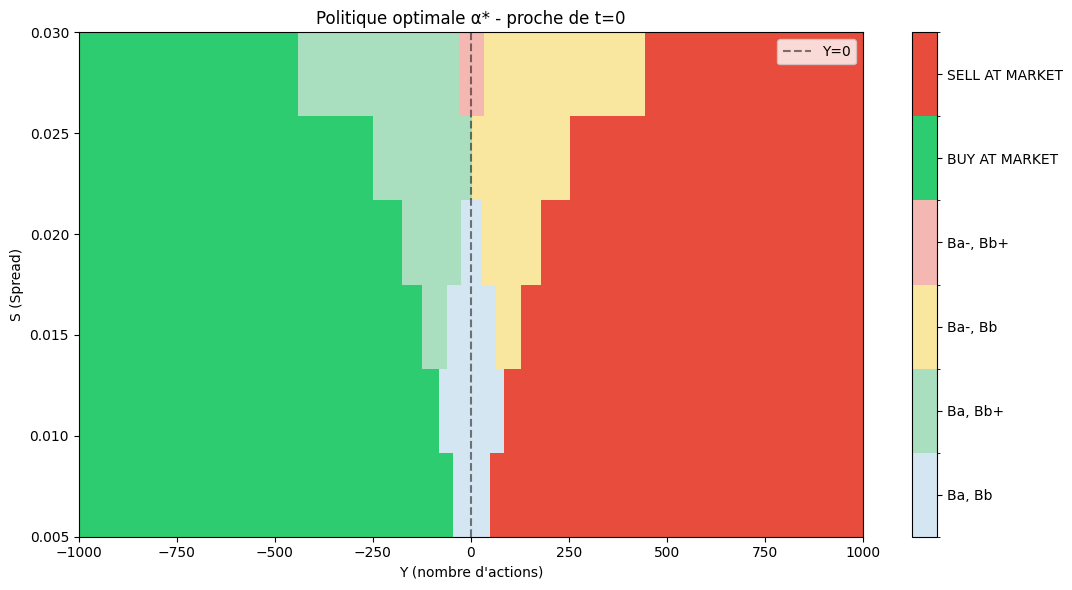

In [ ]:
# Figure 3 (a) : proche de la date 0 (n petit)
plot_policy_slice(pt_opt, pqb_opt, pqa_opt, n_idx=5,
                  title="Politique optimale α* - proche de t=0",
                  fname="figure3a_policy_near_0.png")

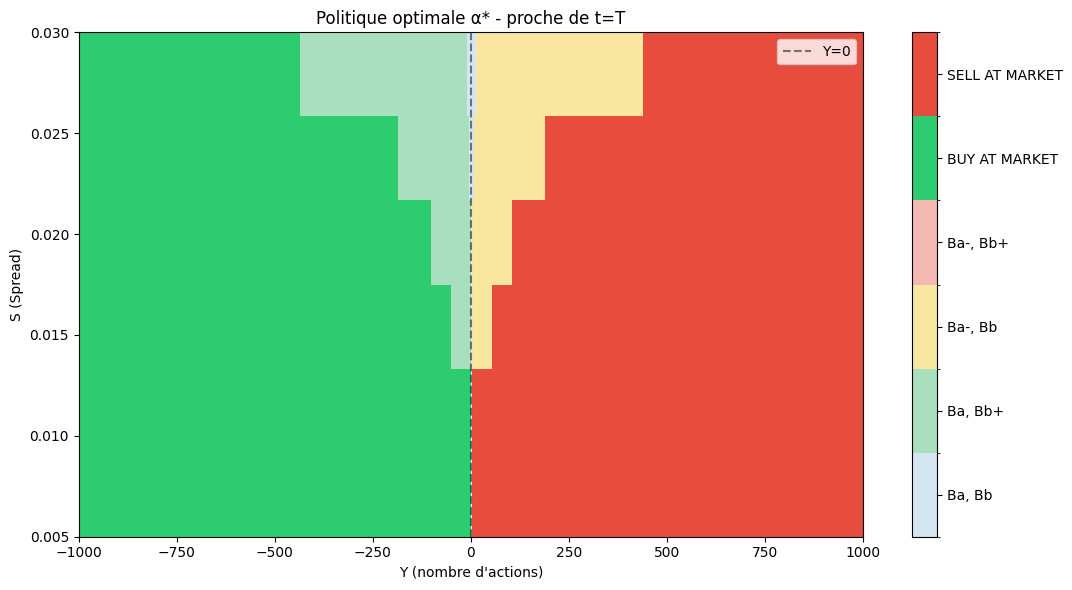

In [ ]:
# Figure 3 (b) : proche de la date T (n grand)
plot_policy_slice(pt_opt, pqb_opt, pqa_opt, n_idx=n_t - 2,
                  title="Politique optimale α* - proche de t=T",
                  fname="figure3b_policy_near_T.png")

## 5. Backtest Monte Carlo

In [ ]:
def y_to_index(y_val):
    """Convertit un inventaire en indice sur la grille Y_grid (avec bornes)."""
    idx = np.round((y_val - y_min) / dy).astype(int)
    return np.clip(idx, 0, N_y - 1)

def simulate_strategies(N_paths, strategies, seed=1):
    """
    Simule N_paths trajectoires en parallèle pour une liste de stratégies.
    Chaque stratégie est un dict avec une fonction 'get_action' qui prend
    (t, n, Y, S, P, rng_arr) et renvoie (use_market, e, qb_idx, lb, qa_idx, la).

    Pour simplifier, on traite chaque stratégie séquentiellement avec les
    mêmes shocks communs (spread, exécutions).

    Retourne un dict : strategy_name -> dict de statistiques + trajectoires.
    """
    rng = np.random.default_rng(seed)
    n_steps = int(T_horizon / dt_sim)
    dt_hjb = T_horizon / n_t

    # Chocs communs : on les génère une fois pour toutes
    # 1) Trajectoires du spread (chaîne de Markov en temps continu)
    # 2) Uniformes pour les exécutions
    # 3) Uniformes pour les transitions de spread
    # 4) Increments browniens pour le prix (modèle Bachelier martingale)
    u_spread = rng.uniform(size=(N_paths, n_steps))
    u_trans  = rng.uniform(size=(N_paths, n_steps))
    u_bid    = rng.uniform(size=(N_paths, n_steps))
    u_ask    = rng.uniform(size=(N_paths, n_steps))
    dW_P     = rng.normal(scale=np.sqrt(dt_sim), size=(N_paths, n_steps))
    # État initial du spread : échantillonné uniformément parmi 1..m
    S = rng.integers(1, m_spreads + 1, size=N_paths)
    # Prix mid initial (modèle Bachelier : dP_t = σ_P dW_t)
    P0_arr = np.full(N_paths, p_0_init)

    results = {}
    for strat_name, strat in strategies.items():
        print(f"  Simulation de la stratégie '{strat_name}'...")
        t0_sim = _clock()

        X = np.full(N_paths, x_0_init)     # cash
        Y = np.full(N_paths, y_0_init, dtype=float)  # inventaire
        P = P0_arr.copy()                   # prix mid, réinitialisé
        N_bid_exec = np.zeros(N_paths, dtype=int)
        N_ask_exec = np.zeros(N_paths, dtype=int)
        N_market_exec = np.zeros(N_paths, dtype=int)
        max_abs_inv = np.zeros(N_paths)

        for step in range(n_steps):
            t = step * dt_sim
            # Indice temporel dans le HJB
            n_hjb = min(int(t / dt_hjb), n_t - 1)

            # 0) Mise à jour du prix mid (Bachelier martingale)
            P = P + sigma_P * dW_P[:, step]

            # 1) Éventuel saut du spread
            # Intensité totale de sortie = λ_const (car Σρ_ij = 1, ρ_ii = 0)
            jump_prob = lambda_const * dt_sim
            # Condition de saut
            mask_jump = u_spread[:, step] < jump_prob
            if mask_jump.any():
                # Transition selon ρ
                for p_idx in np.where(mask_jump)[0]:
                    s_old = S[p_idx] - 1
                    # Échantillonnage dans rho[s_old]
                    cum = np.cumsum(rho_paper[s_old])
                    S[p_idx] = np.searchsorted(cum, u_trans[p_idx, step]) + 1

            # 2) Application de la stratégie
            action = strat['get_action'](t, n_hjb, Y, S, P)
            use_market, e_val, qb_idx, lb_val, qa_idx, la_val = action

            # 3) Ordres market (instantanés)
            if use_market is not None and use_market.any():
                idx_m = np.where(use_market)[0]
                e_m = e_val[idx_m]
                s_m = S[idx_m] * delta
                cost_m = e_m * P[idx_m] + np.abs(e_m) * (s_m / 2 + eps_fee) + eps_0
                # Exécution si e != 0
                nz = e_m != 0
                X[idx_m[nz]] -= cost_m[nz]
                Y[idx_m[nz]] += e_m[nz]
                N_market_exec[idx_m[nz]] += 1

            # 4) Ordres limit (arrivée poissonienne)
            # Seuls les chemins sans market order de cette étape placent des limits
            mask_make = ~use_market if use_market is not None else np.ones(N_paths, dtype=bool)

            if mask_make.any():
                idx = np.where(mask_make)[0]
                Si = S[idx] - 1  # 0..m-1
                # Intensités bid et ask selon (q_b, q_a)
                lam_b = lambda_sym[Si, qb_idx[idx]]
                lam_a = lambda_sym[Si, qa_idx[idx]]
                # Prob exécution sur dt_sim (approximation Euler)
                # Si l=0 pas d'ordre posté donc pas d'exécution
                p_bid_exec = lam_b * dt_sim * (lb_val[idx] > 0)
                p_ask_exec = lam_a * dt_sim * (la_val[idx] > 0)
                exec_bid = u_bid[idx, step] < p_bid_exec
                exec_ask = u_ask[idx, step] < p_ask_exec

                # Prix des ordres limit
                s_idx = Si[exec_bid] * delta if exec_bid.any() else 0
                if exec_bid.any():
                    idx_b = idx[exec_bid]
                    s_b = S[idx_b] * delta
                    qb_b = qb_idx[idx_b]  # 0=Bb, 1=Bb+
                    pi_b = P[idx_b] - s_b / 2 + delta * qb_b - rho_rebate
                    lb_b = lb_val[idx_b]
                    X[idx_b] -= pi_b * lb_b
                    Y[idx_b] += lb_b
                    N_bid_exec[idx_b] += 1

                if exec_ask.any():
                    idx_a = idx[exec_ask]
                    s_a = S[idx_a] * delta
                    qa_a = qa_idx[idx_a]  # 0=Ba, 1=Ba-
                    pi_a = P[idx_a] + s_a / 2 - delta * qa_a + rho_rebate
                    la_a = la_val[idx_a]
                    X[idx_a] += pi_a * la_a
                    Y[idx_a] -= la_a
                    N_ask_exec[idx_a] += 1

            max_abs_inv = np.maximum(max_abs_inv, np.abs(Y))

        # Liquidation finale
        s_T = S * delta
        X_liq = X + Y * P - np.abs(Y) * (s_T / 2 + eps_fee) - eps_0 * (Y != 0)

        results[strat_name] = {
            'X_T': X_liq,
            'N_b': N_bid_exec,
            'N_a': N_ask_exec,
            'N_m': N_market_exec,
            'max_abs_inv': max_abs_inv,
        }
        print(f"    terminé en {_clock() - t0_sim:.1f}s")
    return results

In [ ]:
# Définition des stratégies
def make_optimal_strategy(pt, pe, pqb, plb, pqa, pla):
    """Crée une stratégie à partir des politiques HJB (arrays (n_t, m, N_y))."""
    def get_action(t, n_hjb, Y, S, P):
        y_idx = y_to_index(Y)
        s_idx = S - 1
        use_mk = pt[n_hjb, s_idx, y_idx]
        e_v    = pe[n_hjb, s_idx, y_idx]
        qb_v   = pqb[n_hjb, s_idx, y_idx]
        lb_v   = plb[n_hjb, s_idx, y_idx]
        qa_v   = pqa[n_hjb, s_idx, y_idx]
        la_v   = pla[n_hjb, s_idx, y_idx]
        return use_mk, e_v, qb_v, lb_v, qa_v, la_v
    return get_action

def constant_strategy_action(t, n_hjb, Y, S, P):
    """Toujours au meilleur bid/ask, quantité l_0, pas de market order."""
    N = len(Y)
    use_mk = np.zeros(N, dtype=bool)
    e_v    = np.zeros(N)
    qb_v   = np.zeros(N, dtype=int)   # Bb
    lb_v   = np.full(N, l_0, dtype=float)
    qa_v   = np.zeros(N, dtype=int)   # Ba
    la_v   = np.full(N, l_0, dtype=float)
    return use_mk, e_v, qb_v, lb_v, qa_v, la_v

def make_random_strategy(seed=999):
    """Choix aléatoire du quote (Bb/Bb+, Ba/Ba-), quantité l_0, pas de market."""
    rng_r = np.random.default_rng(seed)
    def get_action(t, n_hjb, Y, S, P):
        N = len(Y)
        use_mk = np.zeros(N, dtype=bool)
        e_v    = np.zeros(N)
        qb_v   = rng_r.integers(0, 2, size=N)
        # Si spread = 1 tick, forcer Bb (qb=0)
        qb_v[S == 1] = 0
        qa_v   = rng_r.integers(0, 2, size=N)
        qa_v[S == 1] = 0
        lb_v   = np.full(N, l_0, dtype=float)
        la_v   = np.full(N, l_0, dtype=float)
        return use_mk, e_v, qb_v, lb_v, qa_v, la_v
    return get_action

strategies = {
    'optimal':  {'get_action': make_optimal_strategy(
        pt_opt, pe_opt, pqb_opt, plb_opt, pqa_opt, pla_opt)},
    'WoMO':     {'get_action': make_optimal_strategy(
        pt_wmo, pe_wmo, pqb_wmo, plb_wmo, pqa_wmo, pla_wmo)},
    'constant': {'get_action': constant_strategy_action},
    'random':   {'get_action': make_random_strategy(seed=999)},
}

In [ ]:
print("\n" + "=" * 70)
print(f"BACKTEST MONTE-CARLO (N_MC = {N_MC} trajectoires)")
print("=" * 70)
t0_bt = _clock()
bt_results = simulate_strategies(N_MC, strategies, seed=1)
print(f"Backtest terminé en {_clock() - t0_bt:.1f}s")


BACKTEST MONTE-CARLO (N_MC = 10000 trajectoires)
  Simulation de la stratégie 'optimal'...
    terminé en 21.6s
  Simulation de la stratégie 'WoMO'...
    terminé en 21.7s
  Simulation de la stratégie 'constant'...
    terminé en 22.3s
  Simulation de la stratégie 'random'...
    terminé en 21.8s
Backtest terminé en 88.1s


### 5.1. Performance

In [ ]:
# Tableau 5 : synthèse de performance
def compute_stats(res):
    """Calcule m(.) et σ(.) pour chaque quantité."""
    X = res['X_T']
    return {
        'IR(X_T)':        X.mean() / X.std(),
        'm(X_T)':         X.mean(),
        'sigma(X_T)':     X.std(),
        'm(N_b)':         res['N_b'].mean(),
        'sigma(N_b)':     res['N_b'].std(),
        'm(N_a)':         res['N_a'].mean(),
        'sigma(N_a)':     res['N_a'].std(),
        'm(N_market)':    res['N_m'].mean(),
        'sigma(N_market)': res['N_m'].std(),
        'm(max|Y|)':      res['max_abs_inv'].mean(),
        'sigma(max|Y|)':  res['max_abs_inv'].std(),
    }

print("\n" + "=" * 70)
print("TABLEAU 5 : Synthèse de l'analyse de performance")
print("=" * 70)
stats = {name: compute_stats(res) for name, res in bt_results.items()}
df_stats = pd.DataFrame(stats)[['optimal', 'WoMO', 'constant', 'random']]
print(df_stats.round(3).to_string())


TABLEAU 5 : Synthèse de l'analyse de performance
                 optimal     WoMO  constant   random
IR(X_T)            3.474    3.265     0.764    0.674
m(X_T)            27.662   25.275    25.104   27.241
sigma(X_T)         7.963    7.741    32.856   40.400
m(N_b)            18.357   17.573    14.020   21.332
sigma(N_b)         3.534    3.157     3.738    4.615
m(N_a)            18.403   17.602    14.078   21.448
sigma(N_a)         3.514    3.138     3.738    4.588
m(N_market)       18.993    0.000     0.000    0.000
sigma(N_market)    4.533    0.000     0.000    0.000
m(max|Y|)        212.724  132.935   611.660  764.830
sigma(max|Y|)     44.432    9.764   273.178  338.680


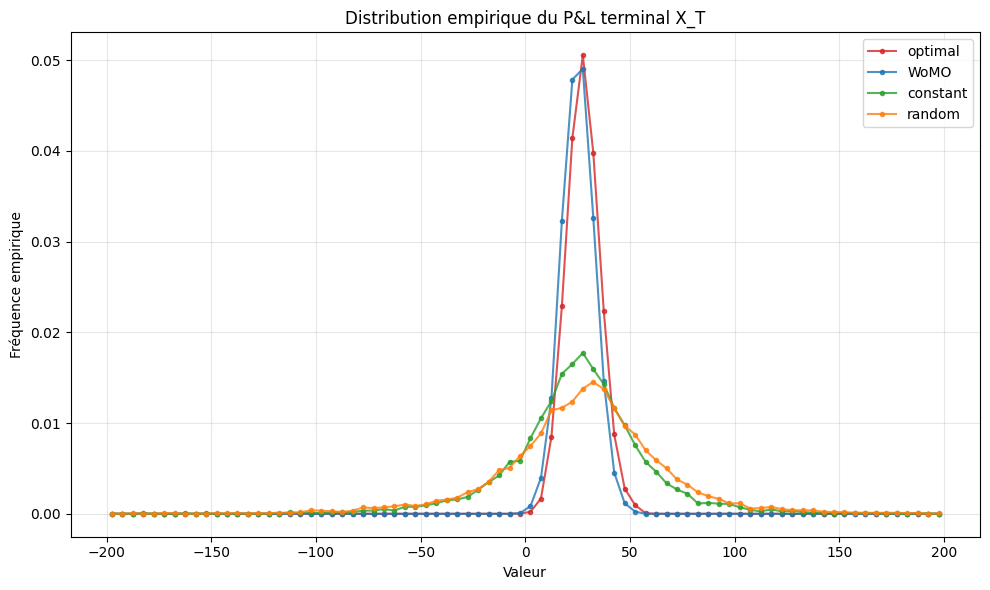

In [ ]:
# Figure 4 : distribution empirique de X_T
fig4, ax4 = plt.subplots(figsize=(10, 6))
colors_4 = {'optimal': 'C3', 'WoMO': 'C0', 'constant': 'C2', 'random': 'C1'}
for name in ['optimal', 'WoMO', 'constant', 'random']:
    X = bt_results[name]['X_T']
    # Histogramme lissé (densité)
    hist, edges = np.histogram(X, bins=80, range=(-200, 200), density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    ax4.plot(centers, hist, marker='o', markersize=3, label=name,
             color=colors_4[name], alpha=0.8)
ax4.set_xlabel('Valeur')
ax4.set_ylabel('Fréquence empirique')
ax4.set_title("Distribution empirique du P&L terminal X_T")
ax4.legend()
ax4.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figure4_XT_distribution.png", bbox_inches='tight')
plt.show()

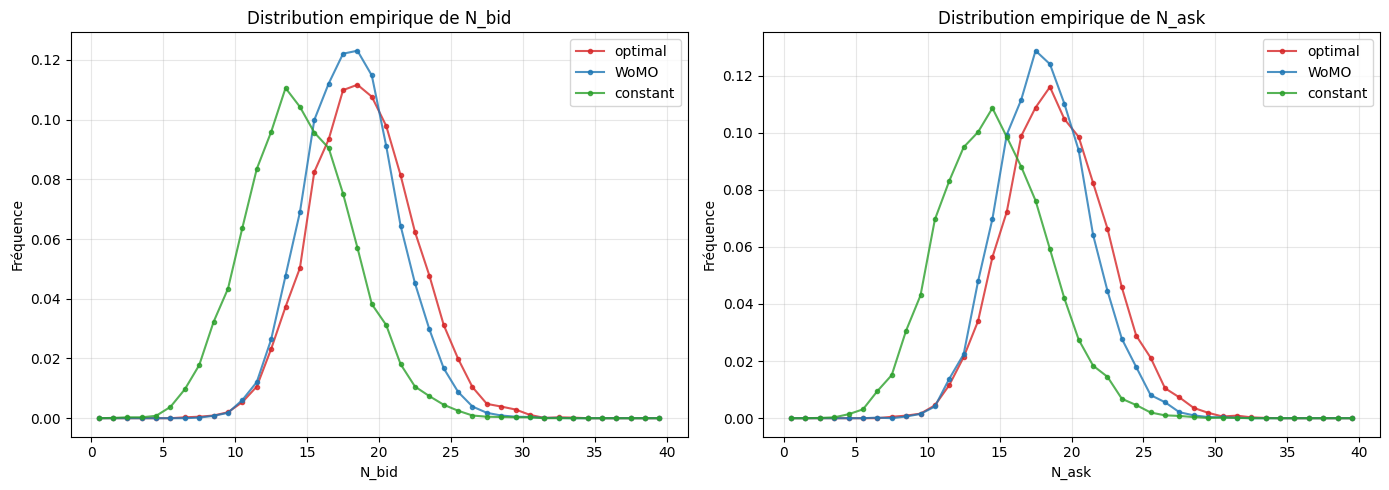

In [ ]:
# Figure 5 : distributions des exécutions au bid et ask
fig5, (ax5a, ax5b) = plt.subplots(1, 2, figsize=(14, 5))
for name in ['optimal', 'WoMO', 'constant']:
    Nb = bt_results[name]['N_b']
    hist_b, edges_b = np.histogram(Nb, bins=40, range=(0, 40), density=True)
    centers_b = 0.5 * (edges_b[:-1] + edges_b[1:])
    ax5a.plot(centers_b, hist_b, marker='o', markersize=3, label=name,
              color=colors_4[name], alpha=0.8)
    Na = bt_results[name]['N_a']
    hist_a, edges_a = np.histogram(Na, bins=40, range=(0, 40), density=True)
    centers_a = 0.5 * (edges_a[:-1] + edges_a[1:])
    ax5b.plot(centers_a, hist_a, marker='o', markersize=3, label=name,
              color=colors_4[name], alpha=0.8)
ax5a.set_title("Distribution empirique de N_bid")
ax5a.set_xlabel("N_bid"); ax5a.set_ylabel("Fréquence")
ax5a.legend(); ax5a.grid(True, alpha=0.3)
ax5b.set_title("Distribution empirique de N_ask")
ax5b.set_xlabel("N_ask"); ax5b.set_ylabel("Fréquence")
ax5b.legend(); ax5b.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figure5_execution_distributions.png", bbox_inches='tight')
plt.show()

### 5.2. Frontière efficiente

In [ ]:
# Tableau 6 et figure 6 : frontière efficiente
print("\n" + "=" * 70)
print("FRONTIÈRE EFFICIENTE (variation de γ)")
print("=" * 70)
gamma_grid = [50.0, 25.0, 12.5, 6.25, 3.125, 1.5625, 0.781, 0.391,
              0.195, 0.098, 0.049, 0.024, 0.012, 0.006]

# Benchmark : m(X_T) de la stratégie constante (pour le NIR)
m_Xc = bt_results['constant']['X_T'].mean()

efficient_data = []
# Réduction de N_MC pour la frontière efficiente (recalcul coûteux)
N_MC_ef = max(2000, N_MC // 5)

for g in gamma_grid:
    print(f"  γ = {g:.3f}")
    # Résolution HJB pour ce γ
    phi_g, pt_g, pe_g, pqb_g, plb_g, pqa_g, pla_g = solve_hjb_qvi(
        gamma=g, enable_market=True, verbose=False)
    phi_gw, pt_gw, pe_gw, pqb_gw, plb_gw, pqa_gw, pla_gw = solve_hjb_qvi(
        gamma=g, enable_market=False, verbose=False)

    strat_g = {
        'optimal': {'get_action': make_optimal_strategy(
            pt_g, pe_g, pqb_g, plb_g, pqa_g, pla_g)},
        'WoMO':    {'get_action': make_optimal_strategy(
            pt_gw, pe_gw, pqb_gw, plb_gw, pqa_gw, pla_gw)},
    }
    res_g = simulate_strategies(N_MC_ef, strat_g, seed=7)

    X_opt = res_g['optimal']['X_T']
    X_wmo = res_g['WoMO']['X_T']

    efficient_data.append({
        'gamma':         g,
        'sigma_opt':     X_opt.std(),
        'm_opt':         X_opt.mean(),
        'sigma_wmo':     X_wmo.std(),
        'm_wmo':         X_wmo.mean(),
        'IR_opt':        X_opt.mean() / X_opt.std(),
        'NIR_opt':       (X_opt.mean() - m_Xc) / X_opt.std(),
    })

df_eff = pd.DataFrame(efficient_data)


FRONTIÈRE EFFICIENTE (variation de γ)
  γ = 50.000
  Simulation de la stratégie 'optimal'...
    terminé en 4.3s
  Simulation de la stratégie 'WoMO'...
    terminé en 5.3s
  γ = 25.000
  Simulation de la stratégie 'optimal'...
    terminé en 5.3s
  Simulation de la stratégie 'WoMO'...
    terminé en 4.2s
  γ = 12.500
  Simulation de la stratégie 'optimal'...
    terminé en 4.7s
  Simulation de la stratégie 'WoMO'...
    terminé en 4.1s
  γ = 6.250
  Simulation de la stratégie 'optimal'...
    terminé en 4.2s
  Simulation de la stratégie 'WoMO'...
    terminé en 4.2s
  γ = 3.125
  Simulation de la stratégie 'optimal'...
    terminé en 4.2s
  Simulation de la stratégie 'WoMO'...
    terminé en 5.1s
  γ = 1.562
  Simulation de la stratégie 'optimal'...
    terminé en 4.1s
  Simulation de la stratégie 'WoMO'...
    terminé en 5.3s
  γ = 0.781
  Simulation de la stratégie 'optimal'...
    terminé en 5.4s
  Simulation de la stratégie 'WoMO'...
    terminé en 4.2s
  γ = 0.391
  Simulation de

In [ ]:
print("\nTABLEAU 6 : Données de la frontière efficiente")
print(df_eff.round(3).to_string(index=False))
df_eff.to_csv("table6_efficient_frontier.csv", index=False)


TABLEAU 6 : Données de la frontière efficiente
 gamma  sigma_opt  m_opt  sigma_wmo  m_wmo  IR_opt  NIR_opt
50.000      2.798  8.384      1.695  5.494   2.996   -5.974
25.000      4.639 14.524      3.455 11.202   3.131   -2.281
12.500      6.304 21.613      5.739 18.977   3.428   -0.554
 6.250      7.618 26.370      7.191 23.614   3.462    0.166
 3.125      8.987 29.707      8.990 27.650   3.305    0.512
 1.562     10.124 31.726     10.786 30.598   3.134    0.654
 0.781     11.688 33.129     12.530 32.423   2.834    0.687
 0.391     13.416 34.162     14.355 33.563   2.546    0.675
 0.195     15.855 35.210     17.148 34.865   2.221    0.637
 0.098     18.479 36.002     19.603 35.389   1.948    0.590
 0.049     21.486 36.375     22.607 35.768   1.693    0.525
 0.024     25.050 36.689     24.540 35.876   1.465    0.462
 0.012     27.126 36.773     26.130 36.019   1.356    0.430
 0.006     28.545 36.772     26.873 36.135   1.288    0.409


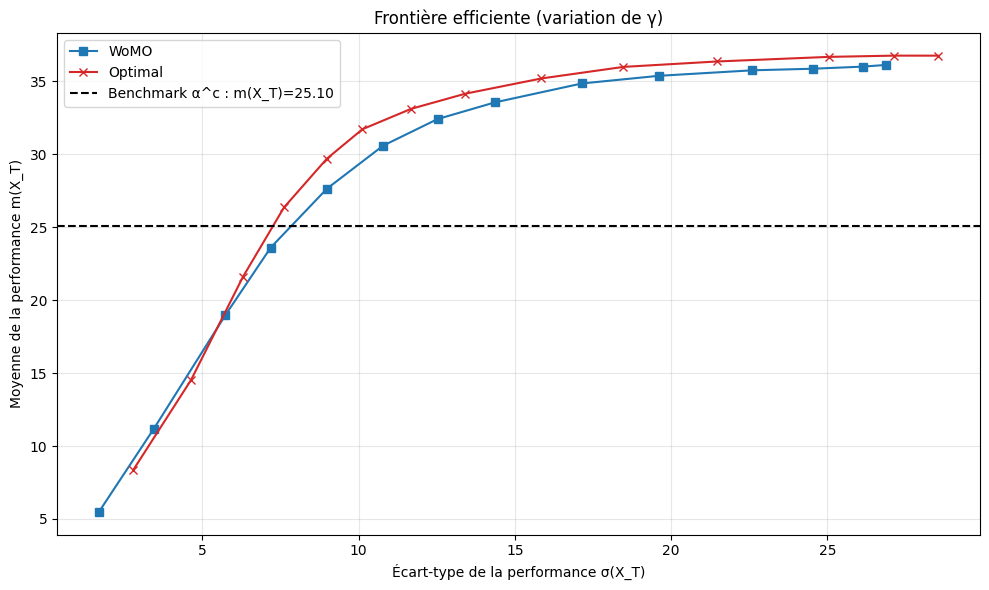

In [ ]:
# Figure 6 : frontière efficiente
fig6, ax6 = plt.subplots(figsize=(10, 6))
ax6.plot(df_eff['sigma_wmo'], df_eff['m_wmo'], marker='s',
         linestyle='-', color='C0', label='WoMO')
ax6.plot(df_eff['sigma_opt'], df_eff['m_opt'], marker='x',
         linestyle='-', color='C3', label='Optimal')
ax6.axhline(m_Xc, linestyle='--', color='k',
            label=f"Benchmark α^c : m(X_T)={m_Xc:.2f}")
ax6.set_xlabel("Écart-type de la performance σ(X_T)")
ax6.set_ylabel("Moyenne de la performance m(X_T)")
ax6.set_title("Frontière efficiente (variation de γ)")
ax6.legend()
ax6.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figure6_efficient_frontier.png", bbox_inches='tight')
plt.show()

In [ ]:
# Indicateurs de surperformance
print("\n" + "=" * 70)
print("INDICATEURS DE SURPERFORMANCE")
print("=" * 70)
m_opt  = bt_results['optimal']['X_T'].mean()
s_opt  = bt_results['optimal']['X_T'].std()
m_wmo  = bt_results['WoMO']['X_T'].mean()
m_ct   = bt_results['constant']['X_T'].mean()
n_trades_opt = (bt_results['optimal']['N_b'].mean()
                + bt_results['optimal']['N_a'].mean()
                + bt_results['optimal']['N_m'].mean())

print(f"(m(X_opt) - m(X_const)) / σ(X_opt) = {(m_opt - m_ct)/s_opt:.3f}")
print(f"(m(X_opt) - m(X_wmo))  / σ(X_opt) = {(m_opt - m_wmo)/s_opt:.3f}")
if n_trades_opt > 0:
    print(f"Surprofit par trade : {(m_opt - m_ct)/n_trades_opt:.4f} euros")


INDICATEURS DE SURPERFORMANCE
(m(X_opt) - m(X_const)) / σ(X_opt) = 0.321
(m(X_opt) - m(X_wmo))  / σ(X_opt) = 0.300
Surprofit par trade : 0.0459 euros
